# 📝 Instrucciones: Campaña de Marketing Bancario

## 1. Comprensión empresarial
Los **depósitos a largo plazo** permiten a los bancos retener capital durante un período específico, facilitando la inversión de estos fondos en otros activos financieros. 

Actualmente, las campañas de marketing para este producto se realizan mediante **llamadas telefónicas**. Si un usuario no está disponible, se programa una nueva llamada para un momento posterior.

## 2. Descripción del problema
Un banco portugués ha detectado una disminución en sus ingresos. Para revertir esta tendencia, necesitan identificar a los clientes existentes con **mayor probabilidad de contratar un depósito a largo plazo**.

**Objetivo:** Crear un algoritmo de clasificación que prediga la suscripción del cliente para optimizar los esfuerzos de marketing, ahorrando tiempo y recursos.

---

## 3. Pasos del Proyecto

### Paso 1: Carga del conjunto de datos
El archivo se encuentra en el repositorio como `bank-marketing-campaign-data.csv`. Puedes cargarlo directamente desde este enlace:

> 🔗 [Descargar Dataset](https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv)

#### Diccionario de Datos:
| Variable | Descripción | Tipo |
| :--- | :--- | :--- |
| **age** | Edad del cliente | Numérico |
| **job** | Tipo de trabajo | Categórico |
| **marital** | Estado civil | Categórico |
| **education** | Nivel de educación | Categórico |
| **default** | ¿Tiene crédito actualmente? | Categórico |
| **housing** | ¿Tiene un préstamo de vivienda? | Categórico |
| **loan** | ¿Tiene un préstamo personal? | Categórico |
| **contact** | Tipo de comunicación de contacto | Categórico |
| **month** | Último mes de contacto | Categórico |
| **day_of_week** | Último día de contacto | Categórico |
| **duration** | Duración del último contacto (segundos) | Numérico |
| **campaign** | Número de contactos en esta campaña | Numérico |
| **pdays** | Días desde el último contacto en campaña previa | Numérico |
| **previous** | Número de contactos previos a esta campaña | Numérico |
| **poutcome** | Resultado de la campaña de marketing anterior | Categórico |
| **emp.var.rate** | Tasa de variación del empleo (trimestral) | Numérico |
| **cons.price.idx**| Índice de precios al consumidor (mensual) | Numérico |
| **cons.conf.idx** | Índice de confianza del consumidor (mensual) | Numérico |
| **euribor3m** | Tasa EURIBOR 3 meses (diario) | Numérico |
| **nr.employed** | Número de empleados (trimestral) | Numérico |
| **y (TARGET)** | ¿El cliente contrata el depósito? | **Categórico** |

### Paso 2: Análisis Exploratorio de Datos (EDA)
Es fundamental realizar un EDA completo para filtrar variables irrelevantes.
* Adapta el Notebook de ejemplo a este caso de uso.
* **Importante:** Divide el conjunto de datos en los sets de **entrenamiento (train)** y **prueba (test)**.

### Paso 3: Construcción del modelo
Construye un modelo de **Regresión Logística**. 
* En esta etapa, utiliza la configuración por defecto de la librería para establecer una línea base.

### Paso 4: Optimización
Si los resultados iniciales no son satisfactorios, aplica técnicas de optimización de hiperparámetros o ingeniería de variables para mejorar la precisión del modelo.

In [273]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import matplotlib.gridspec as gridspec
import os
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier


In [274]:
# Cargamos el dataset usamos el delimitador ";"
total_data = pd.read_csv('../data/raw/bank-marketing-campaign-data.csv',delimiter=";")
#imprimimos los primeros 5
total_data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [275]:
#imprimimos el numero de filas
print(f"Numero De Filas en 'total_data': {len(total_data)}")

# Verificamos La Cantidad De Variables Por Tipos De Datos en total_data que son los datos que vamos a aplicar el EDA:
pd.Series.value_counts(total_data.dtypes)

Numero De Filas en 'total_data': 41188


str        11
int64       5
float64     5
Name: count, dtype: int64

In [276]:
#Obtenemos Información Sobre Los Tipos De Datos Y Valores No Nulos
print("------------------INFO DE total_data--------------------\n")
info = total_data.info()
print("\n\n\n")
print("------------------PORCENTAJE DE VALORES NULOS DEL total_data---------------------\n")
#Obtenemos que columnas tienen valores nulos y el que porcentage respectivamente
(total_data.isna().sum() / len(total_data) * 100).sort_values(ascending = False)

------------------INFO DE total_data--------------------

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-nul

age               0.0
job               0.0
marital           0.0
education         0.0
default           0.0
housing           0.0
loan              0.0
contact           0.0
month             0.0
day_of_week       0.0
duration          0.0
campaign          0.0
pdays             0.0
previous          0.0
poutcome          0.0
emp.var.rate      0.0
cons.price.idx    0.0
cons.conf.idx     0.0
euribor3m         0.0
nr.employed       0.0
y                 0.0
dtype: float64

# Conclusiones (Hasta Ahora):
* Tenemos un dataframe total_data con 20 columnas y 41188  filas
* 5 columnas son int64, 11 str y 5 float64
* Ninguna de esas columnas tienen valores nulos.

In [277]:
# En el ejercicio anterior graficamos los valores nulos pero en este caso no nos encontramos con nulos en ninguna de las variables
# Ahora procederiamos a eliminar duplicados pero no tenemos una columna "id_<algo>" que podamos identificar como primaria de una base de datos en el csv entonses pasamos a
# Revisar Los Posibles Datos Categóricos
total_data.select_dtypes(include = ['str']).columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='str')

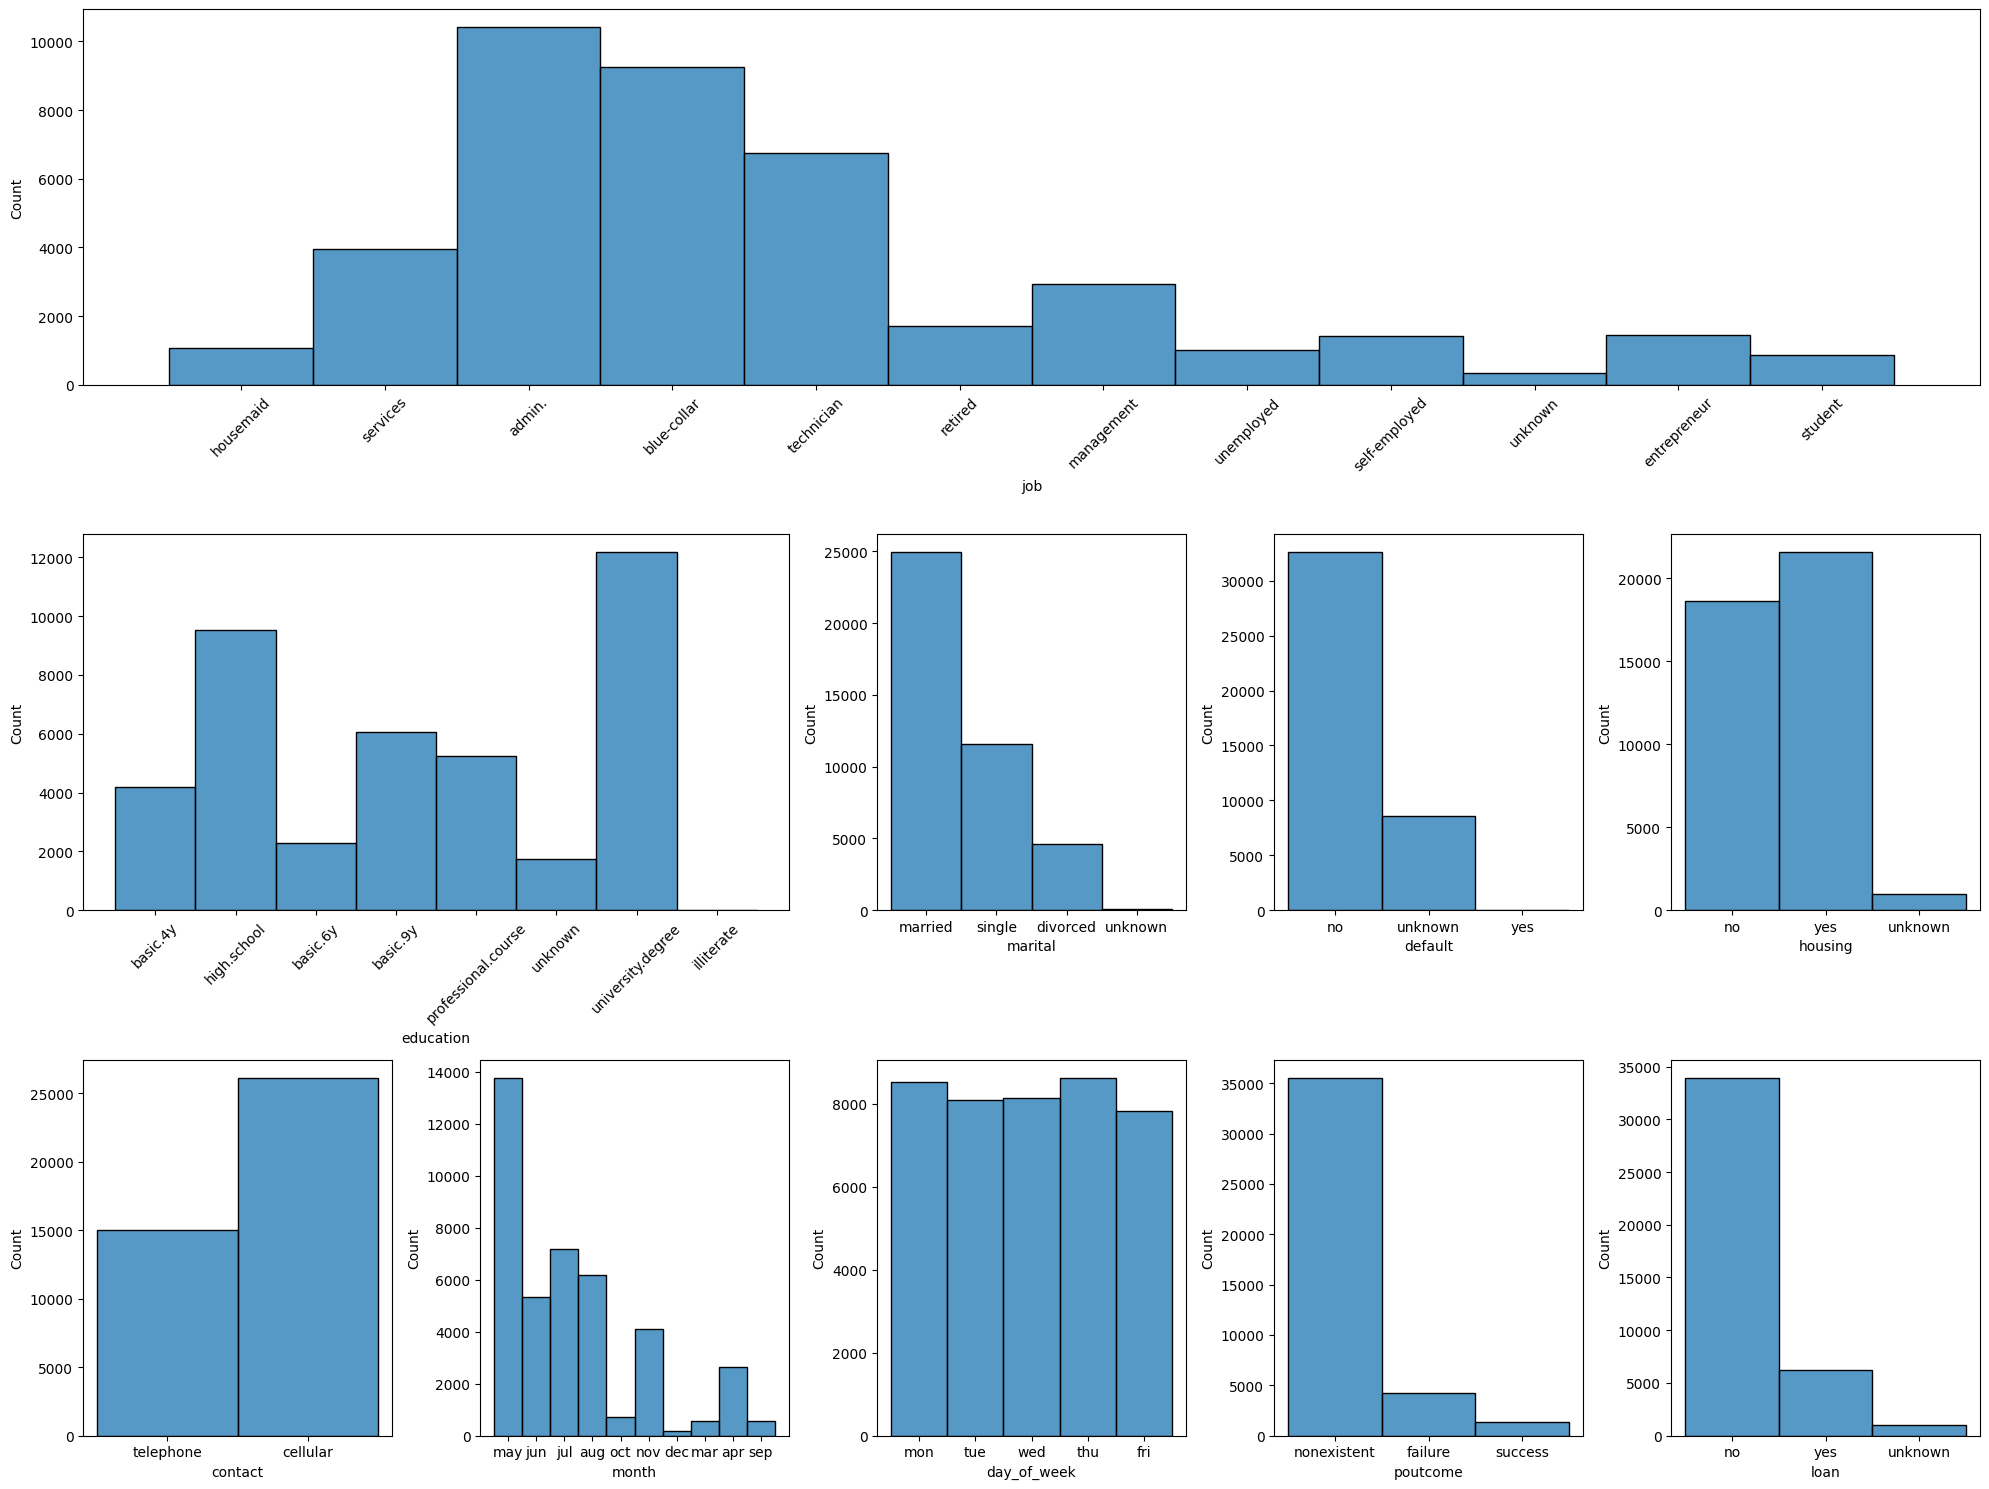

In [278]:
#Creamos Un Histograma Múltiple
fig = plt.figure(figsize=(20, 15))
#Creamos un grid porque necesitaremos hacer unos ajustes de tamaños en algunos graficos, el grid va a ser de 3x5
axis = gridspec.GridSpec(3, 5, figure=fig)
#le decimos al primer grid que ocupe toda la fila
axis0 = fig.add_subplot(axis[0, :])
sns.histplot(data=total_data, x='job', ax=axis0)
#y rotamos un poco los labels
axis0.tick_params(axis='x', rotation=45)
#el segundo grafico va a ocupar 2 espacios
axis1 = fig.add_subplot(axis[1,0:2]); sns.histplot(data=total_data, x='education', ax=axis1)
axis1.tick_params(axis='x', rotation=45)
#el resto solo uno
axis2 = fig.add_subplot(axis[1,2]); sns.histplot(data=total_data, x='marital', ax=axis2)
axis3 = fig.add_subplot(axis[1,3]); sns.histplot(data=total_data, x='default', ax=axis3)
axis4 = fig.add_subplot(axis[1,4]); sns.histplot(data=total_data, x='housing', ax=axis4)
axis6 = fig.add_subplot(axis[2,0]); sns.histplot(data=total_data, x='contact', ax=axis6)
axis7 = fig.add_subplot(axis[2,1]); sns.histplot(data=total_data, x='month', ax=axis7)
axis8 = fig.add_subplot(axis[2,2]); sns.histplot(data=total_data, x='day_of_week', ax=axis8)
axis9 = fig.add_subplot(axis[2,3]); sns.histplot(data=total_data, x='poutcome', ax=axis9)
axis5 = fig.add_subplot(axis[2,4]); sns.histplot(data=total_data, x='loan', ax=axis5)

#Ajustar Layaut
plt.tight_layout()
#Mostramos El Plot
plt.show()

### Son Categorizables?:
#### Analisis e Interpretacion De Columnas(Variables):
| Variable | Descripción | Analisis |
| :--- | :--- | :--- |
| **job** | Tipo de trabajo | Puesto que en ciertos trabajos se manejan conceptos economicos puede servir para nuestro target, ademas el nivel adquisitivo ofrece mas seguridad a la hora de invertir.
| **marital** | Estado civil | Personas solteras suelen tener menos gastos, aunque esto varia si tiene hijos o no, igual son mas propensos a invertir. 
| **education** | Nivel de educación | Parecido al la variable job puede dar señales de conocimientos economicos y de inversion.
| **default** | ¿Tiene crédito actualmente? | Si usuario posee un credito, aunque use un servicio del banco, forma parte del "Dame dinero" y no del "Tomalo e inviertelo" pero el grafico demuestra que la gran mayoria no posee credito actualmente, y el resto se desconoce, se va a descartar esta columna porque no aporta info.
| **housing** | ¿Tiene un préstamo de vivienda? | Igual que el punto anterior pero aca si tenemos datos diversos por lo que lo tendremos en cuenta.
| **loan** | ¿Tiene un préstamo personal? | Igual que el punto anterior aunque disparejo en si posee prestamo o no por lo menos tenemos algunos valores en "yes".
| **contact** | Tipo de comunicación de contacto | Como vimos en el enunciado se suelen ofrecer estos servicios por llamadas puede ser por telefono o celular
| **month** | Último mes de contacto | Si un cliente respondio negativamente a el ultimo contacto, es mas posible que cambie de opinion mientras mas tiempo pase desde el ultimo contacto.
| **day_of_week** | Último día de contacto | Es menos especifico que la variable anterior y pueden solaparse, se puede crear una variable conjunta, el grafico muestra mucha paridad por lo que no nos aporta info relevante por si sola.
| **poutcome** | Resultado de la campaña de marketing anterior | Puede ser usable pero el grafico muestra una mayoria en noexistente, una parte en failiure y un muy minimo "success" que va con la problematica del target quizas haya informacion relevante en esos pocos success. 
| **y (TARGET)** | ¿El cliente contrata el depósito? | Es nuestro Target.
#### Variables Categorizables: 
* job
* marital
* education
* housing
* loan
* contact
* month
* poutcome
* day_of_week
* y
 
 

In [279]:
#reuso mi funcion del ejercicio anterior para guardar cambios en un json pero le modifique que creara el factor el mismo, elimine de una y nombrara la columna factor automaticamente: 
def create_factor_transf_and_json(column, df,folder_name, transformation = False,transformation_func = lambda x: x):
    file_name = ""
        
    if transformation:
         # ahora se le pasa a la funcion una funcion de trnasformacion
        df_aux = df[[column]].copy()
        df[column+"_transf"] = df_aux[column].apply(transformation_func)
        folder_path = '../data/processed/tranformations/' + folder_name
        df_aux = df[[column,column+"_transf"]].copy()
    else:
        #Creo la columna Factor
        df[column+"_factor"] = pd.factorize(df[column])[0]
        folder_path = '../data/processed/factories/' + folder_name
        df_aux = df[[column, column+"_factor"]].copy()
        
    #crea la carpeta si no existe
    os.makedirs(folder_path, exist_ok=True)

    for col in df_aux.columns:
        if pd.api.types.is_datetime64_any_dtype(df_aux[col]):
            df_aux[col] = df_aux[col].dt.strftime('%Y-%m-%d')
    
    # si tranformatios es true creamos renombramos parea que guarde en la carpeta tranformations de otra manera en factories
    if transformation:
        file_name = f'{column}_transformation_rules.json'
        df_to_save = df_aux[[column, column+"_transf"]]
        data_to_export = df_to_save.to_dict(orient = 'records')
    else:
      
        file_name = f'{column}_factory_rules.json'
        df_unique = df_aux[[column, column+"_factor"]].drop_duplicates()
        data_to_export = {row[column]: row[column+"_factor"] for _, row in df_unique.iterrows()}

    full_path = os.path.join(folder_path, file_name)
    with open(full_path, 'w') as f:
        json.dump(data_to_export, f, indent=4)
    #elimino la columna antigua antigua
    df.drop([column],  axis = 1,  inplace = True)
    print(f"Json guardado en: {full_path}")

    

## Rellenar Valores Unknown?:
    En este caso mas que valores erroneos, son desconocimiento de la informacion asi que voy a dejar "Unknown" en las columnas que las tienen como una categoria mas

In [280]:
#Factorizamos las variables categoricas con la funcion "create_factor_transf_and_json_pro_max_2026_full_4k_mediafire_etc"

create_factor_transf_and_json("job", total_data,"BancoEjercicio2")
create_factor_transf_and_json("marital", total_data,"BancoEjercicio2")
create_factor_transf_and_json("education", total_data,"BancoEjercicio2")
create_factor_transf_and_json("housing", total_data,"BancoEjercicio2")
create_factor_transf_and_json("loan", total_data,"BancoEjercicio2")
create_factor_transf_and_json("contact", total_data,"BancoEjercicio2")
create_factor_transf_and_json("month", total_data,"BancoEjercicio2")
create_factor_transf_and_json("poutcome", total_data,"BancoEjercicio2")
create_factor_transf_and_json("day_of_week", total_data,"BancoEjercicio2")
create_factor_transf_and_json("y", total_data,"BancoEjercicio2")
total_data



Json guardado en: ../data/processed/factories/BancoEjercicio2\job_factory_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\marital_factory_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\education_factory_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\housing_factory_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\loan_factory_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\contact_factory_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\month_factory_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\poutcome_factory_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\day_of_week_factory_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\y_factory_rules.json


,age,default,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,...,job_factor,marital_factor,education_factor,housing_factor,loan_factor,contact_factor,month_factor,poutcome_factor,day_of_week_factor,y_factor
0,56,no,261,1,999,0,1.1,93.994,-36.4,4.857,...,0,0,0,0,0,0,0,0,0,0
1,57,unknown,149,1,999,0,1.1,93.994,-36.4,4.857,...,1,0,1,0,0,0,0,0,0,0
2,37,no,226,1,999,0,1.1,93.994,-36.4,4.857,...,1,0,1,1,0,0,0,0,0,0
3,40,no,151,1,999,0,1.1,93.994,-36.4,4.857,...,2,0,2,0,0,0,0,0,0,0
4,56,no,307,1,999,0,1.1,93.994,-36.4,4.857,...,1,0,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,no,334,1,999,0,-1.1,94.767,-50.8,1.028,...,5,0,4,1,0,1,5,0,4,1
41184,46,no,383,1,999,0,-1.1,94.767,-50.8,1.028,...,3,0,4,0,0,1,5,0,4,0
41185,56,no,189,2,999,0,-1.1,94.767,-50.8,1.028,...,5,0,6,1,0,1,5,0,4,0
41186,44,no,442,1,999,0,-1.1,94.767,-50.8,1.028,...,4,0,4,0,0,1,5,0,4,1


In [281]:
# Ahora seleccionamos variables numericas
total_data.select_dtypes(include = ['int', 'float']).columns

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed',
       'job_factor', 'marital_factor', 'education_factor', 'housing_factor',
       'loan_factor', 'contact_factor', 'month_factor', 'poutcome_factor',
       'day_of_week_factor', 'y_factor'],
      dtype='str')

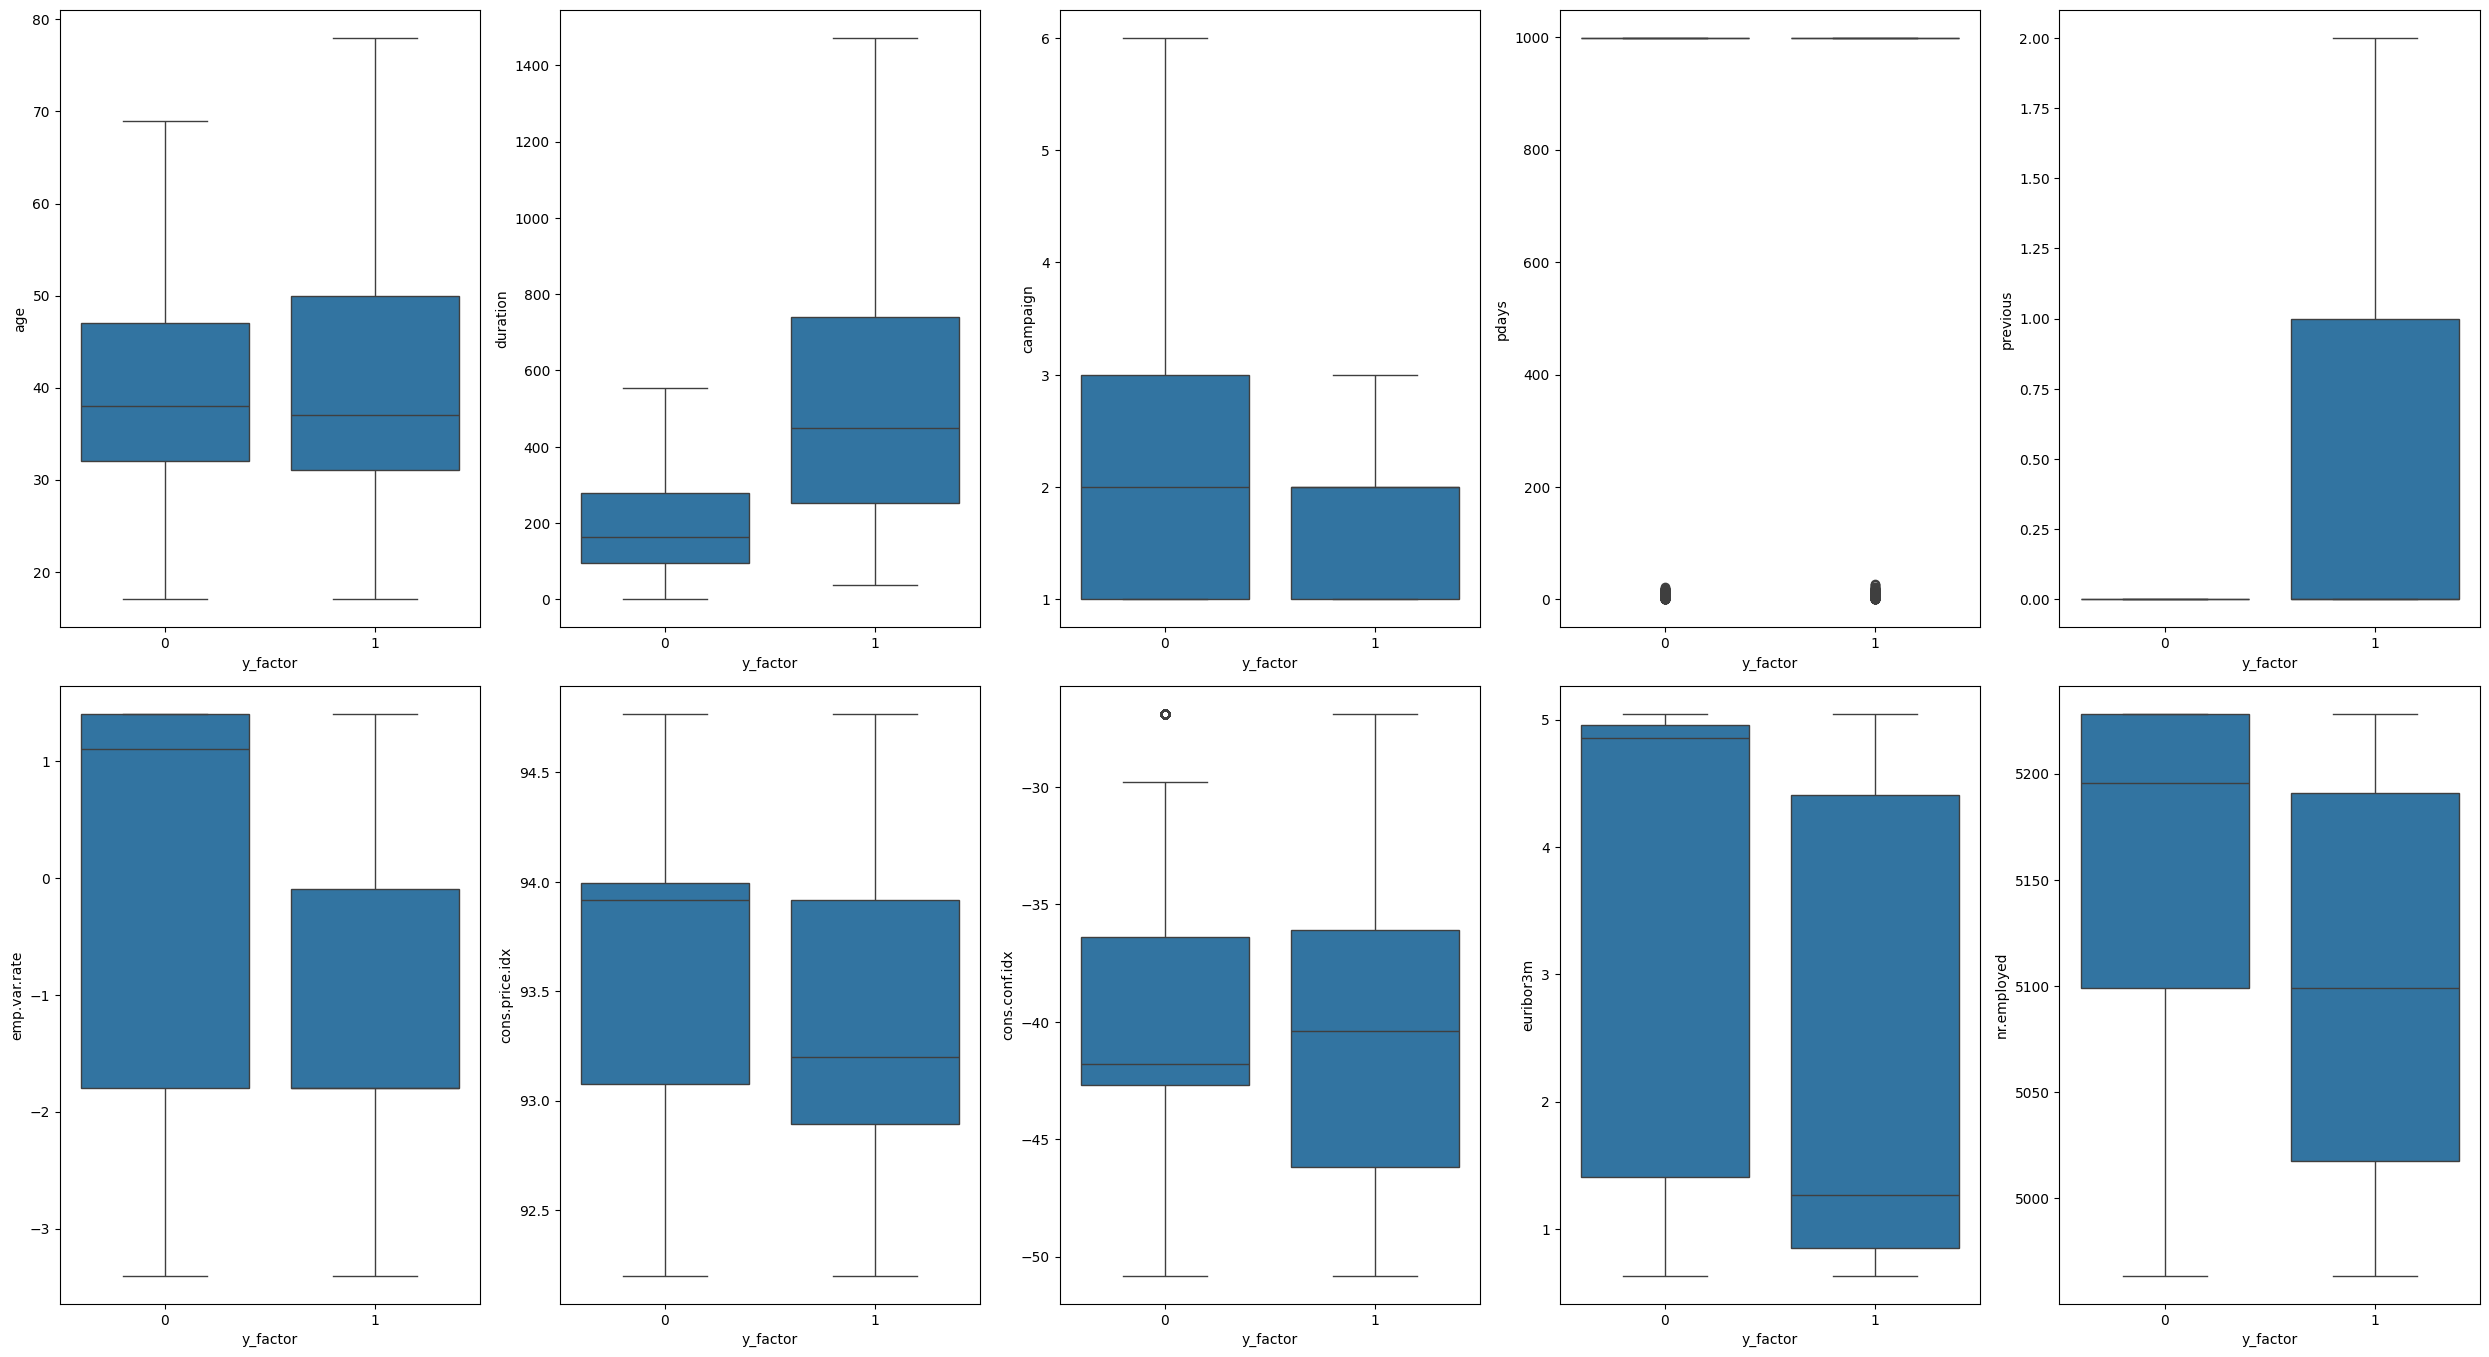

In [282]:
fig = plt.figure(figsize=(25, 20))

# Creamos el grid de 3x5
axis = gridspec.GridSpec(3, 5, figure=fig)

axis0 = fig.add_subplot(axis[0, 0]); sns.boxplot(data = total_data, x = 'y_factor', y = 'age', ax = axis0, showfliers=False)
axis1 = fig.add_subplot(axis[0, 1]); sns.boxplot(data = total_data, x = 'y_factor', y = 'duration', ax = axis1, showfliers=False)
axis2 = fig.add_subplot(axis[0, 2]); sns.boxplot(data = total_data, x = 'y_factor', y = 'campaign', ax = axis2, showfliers=False)
axis4 = fig.add_subplot(axis[0, 4]); sns.boxplot(data = total_data, x = 'y_factor', y = 'previous', ax = axis4, showfliers=False)
axis3 = fig.add_subplot(axis[0, 3]); sns.boxplot(data = total_data, x = 'y_factor', y = 'pdays', ax = axis3)
axis5 = fig.add_subplot(axis[1, 0]); sns.boxplot(data = total_data, x = 'y_factor', y = 'emp.var.rate', ax = axis5)
axis6 = fig.add_subplot(axis[1, 1]); sns.boxplot(data = total_data, x = 'y_factor', y = 'cons.price.idx', ax = axis6)
axis7 = fig.add_subplot(axis[1, 2]); sns.boxplot(data = total_data, x = 'y_factor', y = 'cons.conf.idx', ax = axis7)
axis8 = fig.add_subplot(axis[1, 3]); sns.boxplot(data = total_data, x = 'y_factor', y = 'euribor3m', ax = axis8)
axis9 = fig.add_subplot(axis[1, 4]); sns.boxplot(data = total_data, x = 'y_factor', y = 'nr.employed', ax = axis9)

# Ajustar Layout para que no se solapen los títulos
plt.tight_layout()
plt.show()

#### Analisis e interpretacion de variables(numericas):
| Variable | Descripción | Analisis |
| :--- | :--- | :--- |
| **age** | Edad del cliente | Las Dos Cajas son muy parecidas pero el bigote de los que contrataron el servicio esta un poco mas alto, puede indicar que personas por encima de los 70 años son mas propensas a contratar el servicio |
| **duration** | Duración del último contacto (segundos) | Aca vemos que la segunda caja casi supera a la primera, indicante que mientras mmas dure la llamada es mas la persona es mas propensa a contratar el servicio, Las otras probablemente colgaron o dirjeron un rotundo "No, Gracias"  |
| **campaign** | Número de contactos en esta campaña | La primera Caja es significativamente mas alta que la segunda, se puede concluir aca que por mas llamadas que se hagan a un cliente no cambiaran de opinion la mayoria de las veces. |
| **pdays** | Días desde el último contacto en campaña previa | podemos observar que ni se ven las cajas casi todos los valores estan cerca de 1000 casi que diciendonos que no ha habido contacto(podemos decir esos valores en 1000 representan nada en lugar de dias), aca los outliers pueden significar algo pero al ser tan pocos vamos a dropear esta variable. |
| **previous** | Número de contactos previos a esta campaña | podemos observar que los datos de la primera caja estan comprimidos o aplastados haciendo que la mayoria de los datos esten aca, podemos decir que la mayoria son clientes nuevos, pero hay unos pocos que representan la segunda caja e indican que puede haber fidelidad de clientes que hayan sido contactado antes. |
| **emp.var.rate** | Tasa de variación del empleo (trimestral) | Un variable con resultados extraños, mientras cuando las variacion de empleo en positivo (es decir estables) no provocaron que los clientes contrataran, la variacion negativa de la segunda caja (la media que es -1.8 aprox) nos indica que mientras menos estable fue el empleo mas contrataciones hubo. |
| **cons.price.idx**| Índice de precios al consumidor (mensual) | esta variable ya es un poco mas consistente representa la inflacion, mientras que la primera caja hubo in indice alto(cosas mas caras) no hubo contrato, por otra parte la segunda caja que tiene una media mas baja, indica que si hubo menos imflacion(cosas mas baratas) las personas fueron mas propensas a depositar. |
| **cons.conf.idx** | Índice de confianza del consumidor (mensual) | ambas cajas estan en negativo y sus medias se paracen, indica que aunque algunos contrataron y otros no, ambos estan pesimistas pero la segunda caja esta ligeramente por arriba, haciendo que si eres menos pesimista seas mas propenso a contratar el servicio a largo plazo del banco. |
| **euribor3m** | Tasa EURIBOR 3 meses (diario) | El EURIBOR son los intereses que se pagan los bancos entre si, aunque no afecta directamente al cliente,indirectamente afecta a los intereses que les da el banco, pero en nuestro grafico la media de la primera caja 4.8 aprox es mas alta que la segunda 1.3 aprox es un poco contradictorio pero puede tener que ver con la especulacion cuando hay intereses altos |
| **nr.employed** | Número de empleados (trimestral) | Otro punto extraño, cuando hubo mas empleabilidad hubieron menos adquisicion de servicios, puede indicar que el banco tiene mejor exito en las crisis, suele pasar con algunas empresas que aprovenchan las crisi como oportunidades |

In [283]:
#Eliminamos la coluna pdays y default que habiamos dicho antes que la ibamos a eliminar
total_data.drop(["pdays","default"],  axis = 1,  inplace = True)
total_data.head()

,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_factor,marital_factor,education_factor,housing_factor,loan_factor,contact_factor,month_factor,poutcome_factor,day_of_week_factor,y_factor
0,56,261,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0,0,0,0,0,0,0
1,57,149,1,0,1.1,93.994,-36.4,4.857,5191.0,1,0,1,0,0,0,0,0,0,0
2,37,226,1,0,1.1,93.994,-36.4,4.857,5191.0,1,0,1,1,0,0,0,0,0,0
3,40,151,1,0,1.1,93.994,-36.4,4.857,5191.0,2,0,2,0,0,0,0,0,0,0
4,56,307,1,0,1.1,93.994,-36.4,4.857,5191.0,1,0,1,0,1,0,0,0,0,0


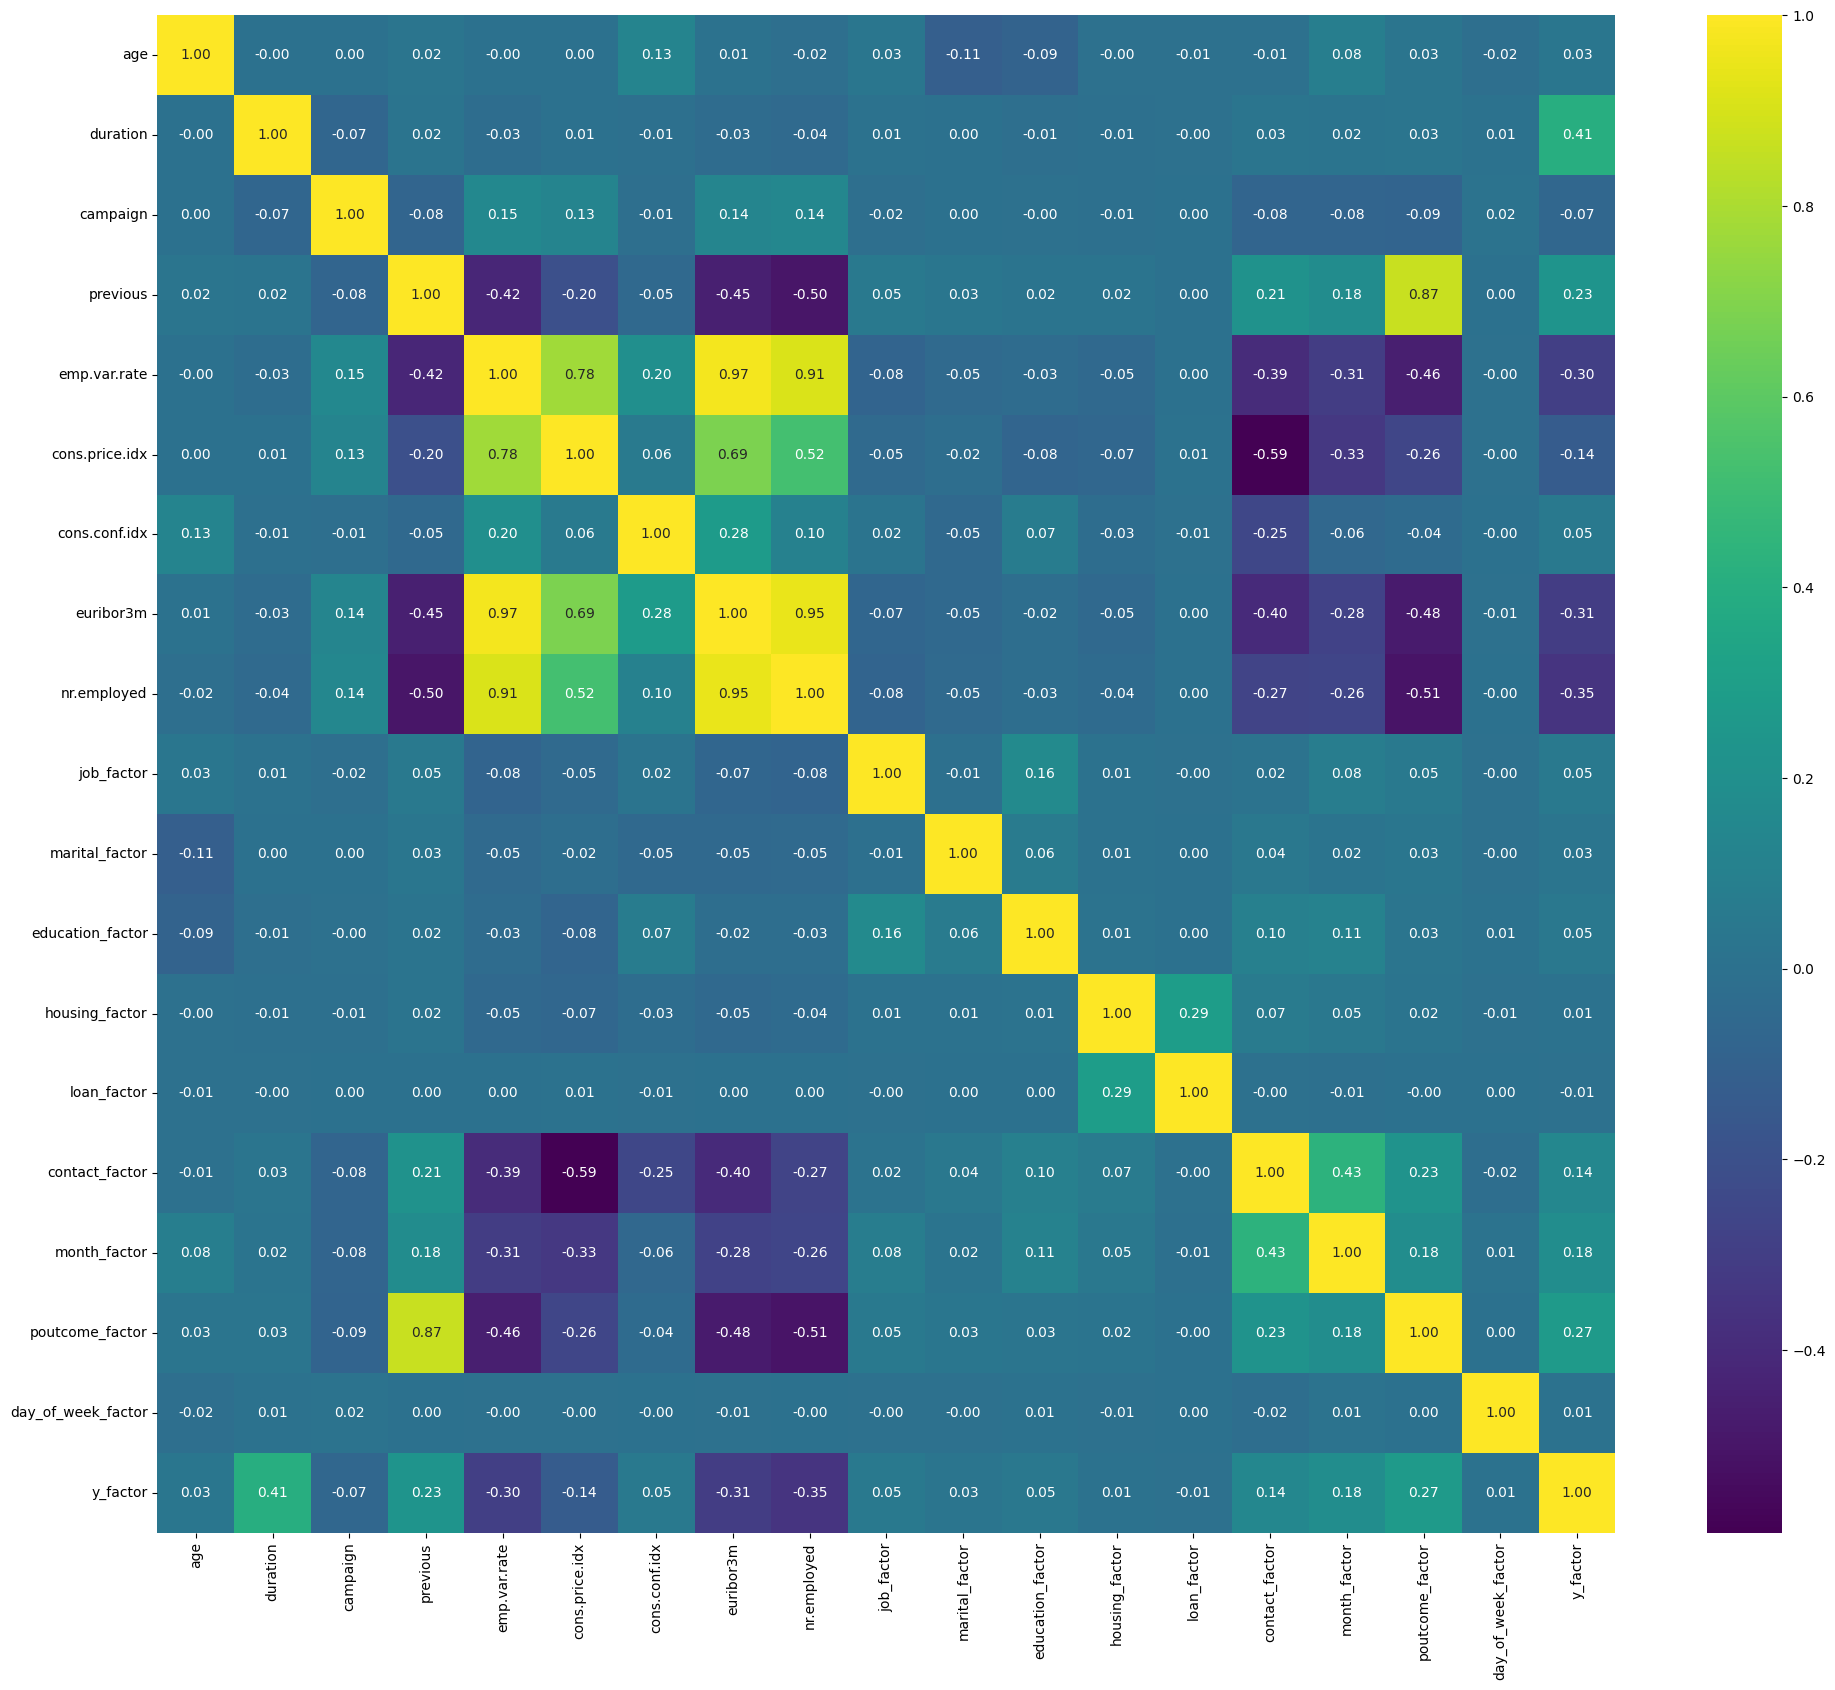

In [284]:
#Graficamos en un heatmap para ver las correlaciones
cols_num = total_data.select_dtypes(include=['number']).columns
fig, ax = plt.subplots(figsize=(20,  17))
sns.heatmap(total_data[cols_num].corr(method = "pearson"), annot = True, fmt = ".2f", cmap = "viridis",ax = ax)
plt.tight_layout()
plt.show()

### Interpretacion del grafico
Es un grafico bastante extenso pero nos vamos a enfocar en las correlaciones de nuestro target **y_factor** buscaremos valores <= -0.10 y >= 0.10, ademas tomaremos valores >= 0.7 como redundantes:
* `Duration`: Nuestro mejor indicador 0.41, ademas nuestro grafico de cajas tambien lo coloca como candidata
* `Previous`: Con un 0.23 lo vamos a dejar dado que en el grafico de cajas habia una minoria de clientes que usaron el servicio.
* `emp.var.rate`, `euribor3m` y `nr.employed`: poseen correlaciones parecidas -0.30,-0.31 y -0.35 respectivamente, pueden ser redundantes entre si, ya que las correlaciones entre ellos van desde 0.91 hasta 0.97. nos quedamos con nr.employed que es mas alto.
* `cons.price.idx`: Tiene un factor de -0.14 en el punto anterrior nos quedanmos con `nr.employed` y la correlacion con este es de 0.52, podria ser redundante pero no necesariamente asi que nos quedaremos con estos dos.
* `poutcome_factor`: con un 0.27 a primera vista tambien es un buen indicador pero la mayoria de sus datos son "inexistente", sin embargo al ser el resultado de una campaña anterior es una variable muy importante aunque nos de solo unos pocos datos de los que usaron el servicio.
* `contact_factor`: 0.15, no tan alto pero ya vimos si puede haber una tendencia, Lo dejamos para ver si el canal de comunicación influye en la tasa de éxito.
* `month_factor`: 0.19, tambien vimos que el tiempo del ultimo contacto influye asi que lo dejamos.

In [285]:
# No se si me servira en un futuro en los siguientes ejercicios pero cree una funcion que haga el split,los scalers, separe los outliers y guarde los limites en un json de una vez.
def train_prepare_test_data(df, target_col,folder_name, test_size=0.2, random_state=42, scaler_type=1, stratify = False):
 
    # Separamos X e y
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    # hacemos el split dependiendo del valor de stractify, stractify le dice al split que intente dividirlos distribuyendo bien los valores de una columna
    if stratify:
        x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify = y)
    else:
        x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    # Copiamos para crear los outliers y escalar sin destruir los originales
    x_train_out = x_train.copy()
    x_test_out = x_test.copy()
    
    # creamos un diccionario limpio para almacenar los limites mas adelante
    outlier_limits = {}
    # buscamos las variables numericas
    numeric_cols = x_train_out.select_dtypes(include=["number"]).columns
    
    #luego recorremos las columnas
    for col in numeric_cols:
        # calculamos el Rango Intercuartil como vimos en clases (IQR), que requiere del primer quartil y el tercero
        Q1 = x_train_out[col].quantile(0.25)
        Q3 = x_train_out[col].quantile(0.75)
        IQR = Q3 - Q1
        #nuestro limite bajo
        low = Q1 - 1.5 * IQR
        #nuestro limite alto
        high = Q3 + 1.5 * IQR
        
        # Guardamos los limites
        outlier_limits[col] = {"lower_bound": float(low), "upper_bound": float(high)}
        
        # suavizamos los outliers, baiscamente si es mayor high lo convierte en high y si es menor a low lo convierte a low
        x_train_out[col] = np.clip(x_train_out[col], low, high)
        x_test_out[col] = np.clip(x_test_out[col], low, high)
        
    #Creamos la carpeta si no existe
    path = f"../data/processed/outliers/{folder_name}/"
    if not os.path.exists(path):
        os.makedirs(path)
    # Guardardamos los limites en un JSON
    with open(f"{path}outlier_limits.json", "w") as f:
        json.dump(outlier_limits, f, indent=4)
        
    # Escalamos dependiendo de la variable scaler_type puede se StandardScaler, MinMaxScaler

    if scaler_type == 1:
        sc = StandardScaler()
         # Aprende Y Transforma El Train Normal
        x_train[numeric_cols] = sc.fit_transform(x_train[numeric_cols])
        
        # Solo Transforma El Resto
        x_test[numeric_cols] = sc.transform(x_test[numeric_cols])
        x_train_out[numeric_cols] = sc.transform(x_train_out[numeric_cols])
        x_test_out[numeric_cols] = sc.transform(x_test_out[numeric_cols])
        
    elif scaler_type == 2:
        mx = MinMaxScaler()
        # Aprende Y Transforma El Train Normal
        x_train[numeric_cols] = mx.fit_transform(x_train[numeric_cols])
        
        # Solo Transforma El Resto
        x_test[numeric_cols] = mx.transform(x_test[numeric_cols])
        x_train_out[numeric_cols] = mx.transform(x_train_out[numeric_cols])
        x_test_out[numeric_cols] = mx.transform(x_test_out[numeric_cols])
   
    return x_train, x_test, y_train, y_test, x_train_out, x_test_out

In [286]:
#ejecutamos la funcion y guardamos los resultados en variables
# en este caso ponemos stractify true porque nuestro target y = 1 que son muy pocos valores en relacion a y = 0.
x_train, x_test, y_train, y_test, x_train_out, x_test_out = train_prepare_test_data(total_data, "y_factor", "BancoEjercicio2", scaler_type = 1,stratify = True)
x_train_out.head()

,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_factor,marital_factor,education_factor,housing_factor,loan_factor,contact_factor,month_factor,poutcome_factor,day_of_week_factor
25611,0.863739,-0.120196,0.522981,-0.350127,-0.114858,-0.648967,-0.322269,0.288964,0.398990,-0.271982,-0.732357,-0.128309,-1.056399,-0.43938,0.758915,1.134460,-0.374417,0.012175
26010,-0.289722,-0.216732,-0.203688,-0.350127,-0.114858,-0.648967,-0.322269,0.288964,0.398990,1.358846,-0.732357,1.245091,-1.056399,-0.43938,-1.317671,1.134460,-0.374417,0.012175
40194,2.834234,1.486155,-0.567023,-0.350127,-1.133161,1.103451,0.045048,-1.583296,-2.420139,0.543432,-0.732357,-1.501709,-1.056399,-0.43938,0.758915,-0.102089,-0.374417,-1.402820
297,-0.385843,-0.533368,-0.203688,-0.350127,0.648868,0.721890,0.887717,0.713535,0.332723,-0.679689,-0.732357,1.245091,0.790589,-0.43938,-1.317671,-0.926454,-0.374417,-1.402820
36344,1.824956,0.424264,-0.203688,-0.350127,-1.896888,-1.058152,-0.062987,-1.357472,-1.252175,0.543432,2.140059,1.245091,-1.056399,-0.43938,0.758915,-0.514272,-0.374417,-0.695323



Ranking de variables por F-score:
               Feature      F-Score
1             duration  6303.936492
8          nr.employed  4591.467371
7            euribor3m  3334.921621
4         emp.var.rate  3110.163775
16     poutcome_factor  2621.559490
3             previous  1836.226549
15        month_factor  1159.749593
14      contact_factor   690.157641
5       cons.price.idx   588.964243
2             campaign   141.797340
9           job_factor   109.215395
6        cons.conf.idx   101.165877
11    education_factor    73.776619
0                  age    27.109901
10      marital_factor    23.139103
12      housing_factor     2.682659
17  day_of_week_factor     2.294486
13         loan_factor     0.002152


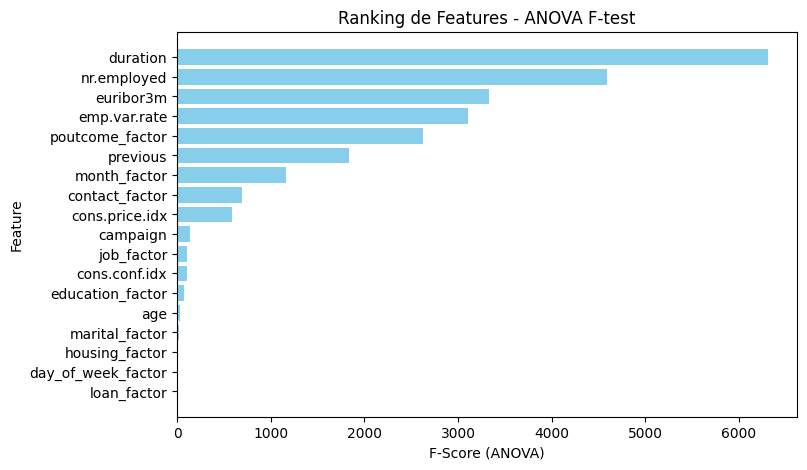

In [287]:
#vamos a tomar del collab el codigo para encontrar los F-scores y graficarlos  
pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),           # rellenar NaN con la mediana
    ("selector", SelectKBest(score_func=f_classif, k=5))    # seleccionar las 5 mejores variables
])

# Ajusto el pipeline antes de acceder a los scores
pipe.fit(x_train, y_train)
scores = pipe.named_steps["selector"].scores_
feature_scores = pd.DataFrame({
    "Feature": x_train.columns,
    "F-Score": scores
}).sort_values(by="F-Score", ascending=False)

print("\nRanking de variables por F-score:")
print(feature_scores)

#Grafico Barras Con La Imporancia De Cada Variable
plt.figure(figsize=(8,5))
plt.barh(feature_scores["Feature"], feature_scores["F-Score"], color='skyblue')
plt.xlabel("F-Score (ANOVA)")
plt.ylabel("Feature")
plt.title("Ranking de Features - ANOVA F-test")
plt.gca().invert_yaxis()  # invertir eje para que la mejor aparezca arriba
plt.show()

In [288]:
# Nos quedamos con los indicadores que nos interesan
columns_list = ["previous","duration", "poutcome_factor", "contact_factor", "month_factor", "cons.price.idx", "nr.employed", "y_factor"]
#Creamos una copia por si no obtenemos buenos resultados y necesitamos reinsertar variables
df_model = total_data[columns_list].copy()
#volvemos a crear los x_train,x_test etc con las columnas nuevas
x_train, x_test, y_train, y_test, x_train_out, x_test_out = train_prepare_test_data(df_model, "y_factor", "BancoEjercicio2", scaler_type = 1,stratify = True)

In [289]:
# meti la logica de entrenar al modelo porque creo que lo voy a necesitar mas de una ves, se le pasa los x_test el class_weight que es un diccionario con la proporcion de clases, 
# el max_iter son maximas iteraciones y el umbral para ajustar la sensibilidad del modelo
def train_print_model(x_test, y_test, x_test_out,type_model="lg", class_weight=None, max_iter=10000,max_depth=7, umbral=0.5):
    # Preparo El Modelo dependiendo del valor de class_weight y el tipo de modelo seleccionado
    if type_model == "lg":
        model = LogisticRegression(class_weight=class_weight, max_iter=max_iter)
        model_out = LogisticRegression(class_weight=class_weight, max_iter=max_iter)
    elif type_model == "rf":
        # Para Random Forest usamos n_estimators. El class_weight funciona igual.
        model = RandomForestClassifier(n_estimators=200, class_weight=class_weight, random_state=42,max_depth=max_depth)
        model_out = RandomForestClassifier(n_estimators=200, class_weight=class_weight, random_state=42,max_depth=max_depth)

    # entrenamos (usando las variables globales x_train y x_train_out)
    model.fit(x_train, y_train)
    model_out.fit(x_train_out, y_train)
    
    # Obtener Probabilidades (en lugar de clases directas)
    # antes usaba predict pero para modificar el umbral necesito predict_proba
    probs = model.predict_proba(x_test)[:, 1]
    probs_out = model_out.predict_proba(x_test_out)[:, 1]

    # Aplico el umbral
    predictions = (probs >= umbral).astype(int)
    predictions_out = (probs_out >= umbral).astype(int)
    
    # Revisamos Las Métricas De Clasificacion como esta en el collab
    report = classification_report(y_test, predictions)
    report_out = classification_report(y_test, predictions_out)
    
    print(f"--- Reporte de Modelo: {type_model.upper()} (Umbral: {umbral}) ---")
    print("Reporte Sin Outliers:\n")
    print(report)
    print("Reporte Con Outliers:\n")
    print(report_out)

In [290]:
#aplicamos la funcion sin balancear y sin umbral
train_print_model(x_test,y_test,x_test_out)

--- Reporte de Modelo: LG (Umbral: 0.5) ---
Reporte Sin Outliers:

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7310
           1       0.67      0.36      0.46       928

    accuracy                           0.91      8238
   macro avg       0.79      0.67      0.71      8238
weighted avg       0.89      0.91      0.89      8238

Reporte Con Outliers:

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7310
           1       0.64      0.35      0.45       928

    accuracy                           0.90      8238
   macro avg       0.78      0.66      0.70      8238
weighted avg       0.89      0.90      0.89      8238



## Analisis
* Los resultados no son del todo buenos, para 0(no contrata) que no nos intereza hay una presicion,recall,f1-score bastante altos, pero nos interesa el 1(si contrata), es de esperar porque el support de 0 es alto: 7310 y el de 1 bajo:928
* Con outliers el resultado no mejora

Vamos a intentar hacer unos ajustes

In [291]:
#anteriormente eliminamos esta columna porque podria ser redundante, vamos a traerla devuelta a ver que pasa
columns_list.append("euribor3m")
#otra ves creamos una copia y volvemos a crear los x_train,x_test etc con las columnas nuevas
df_model = total_data[columns_list].copy()
x_train, x_test, y_train, y_test, x_train_out, x_test_out = train_prepare_test_data(df_model, "y_factor", "BancoEjercicio2", scaler_type = 1,stratify = True)

# cambiamos las proporciones para class_weight, en{0:1} le decimos que si se equivoca con 0, "no se castigue" puesto que son los clientes no iban a depositar, con
# {1: 6} le estamos diciendo que 1 vale 6 puntos, es decir si se equivoca el "castigo" va a ser 6 veces mayor, hay que buscar un punto ni tan alto y ni tan bajo
# porque si le decimos que se "castigue aun mas" digamos que el modelo puede "desesperarse" por encontrar unos y empieza a disparar a todo lo que se mueve bajando
# la presicion
proporciones = {0: 1, 1: 6}
# ademas de eso le especificamos a mi funcion "train_print_model" que use "RandomForestClassifier" en lugar de "LogisticRegretion" esto lo hago pasandole este parametro
# type_model="rf", max_depth=10 son las preguntas seguidas que hace el "arbol" osea las 10 mas importantes que tengan un f-score mas alto.
# y por ultimo modificamos el umbral, por defecto esta en 0.5 pero como tenemos datos desiguales aumentamos el umbral a 0.861 diciendole que solo arroje un positivo
# cuando este un 86.1% seguro
train_print_model(x_test,y_test,x_test_out,type_model="rf",class_weight=proporciones,max_depth=10,umbral=0.861)

--- Reporte de Modelo: RF (Umbral: 0.861) ---
Reporte Sin Outliers:

              precision    recall  f1-score   support

           0       0.92      0.99      0.95      7310
           1       0.80      0.31      0.44       928

    accuracy                           0.91      8238
   macro avg       0.86      0.65      0.70      8238
weighted avg       0.90      0.91      0.90      8238

Reporte Con Outliers:

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7310
           1       0.71      0.35      0.47       928

    accuracy                           0.91      8238
   macro avg       0.82      0.67      0.71      8238
weighted avg       0.90      0.91      0.90      8238



## Conclusiones Finales:
* Se tiene una muy buena presicion de clientes que no usarian el servicio del banco(0), pero es el contrario a lo que queremos.
* Inicialmente se uso LogisticRegretion como modelo, pero se cambio a RandomForest porque se obtenian resultados no presisos en clientes que usarian el servicio del banco(1).
* Se añadio la columna euribor3m, se creia redundante en un principio pero resulto mejorar el modelo al final.
* Modificando las proporciones de clases y el umbral se logro una presicion del modelo de 0.80 y un recall de 0.31, si se subia el umbral subia la precision pero bajaba mucho el recall, si el recall baja mucho se piede la sensibilidad de detectar potenciales clientes, es decir, si subimos la presicion a costa del recall acertaremos con los clientes pero seran muy pocos.